# 02 · Scaling PCA: Randomized PCA, Incremental PCA and memory-mapped data

**Question:** what happens when the data is large? Is the randomized solver faster, does Incremental PCA find the same components, and does it really run *out of core*?

Method: Géron Ch. 8, *Randomized PCA* and *Incremental PCA* (pp. 227-228). Each solver is timed (median of 3 runs; solvers slower than 30 s run once). Its peak memory is traced with `tracemalloc` in a separate run (NumPy reports its buffers to it). Its components are compared with the exact SVD through the test reconstruction error.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dimred_mlops.config import load_config
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
CFG = load_config(ROOT / "configs/full_flow_config.yaml")
SEED = CFG["seed"]
# figures are drawn into a temporary folder: reports/figures belongs to the pipeline run
import tempfile
FIG = Path(tempfile.mkdtemp(prefix="nb-figures-"))

In [2]:
from dimred_mlops.data import load_mnist_split
split = load_mnist_split(ROOT / "data")     # first 60,000 = train, last 10,000 = test
X_train, y_train, X_test, y_test = split.X_train, split.y_train, split.X_test, split.y_test
split.sizes

{'n_train': 60000, 'n_test': 10000, 'n_features': 784}

## 1. The book's three snippets

In [3]:
import time
from sklearn.decomposition import PCA, IncrementalPCA
t = time.perf_counter(); rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=SEED).fit(X_train)
print(f"Randomized PCA: {time.perf_counter() - t:.1f} s")
t = time.perf_counter()
n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)
print(f"Incremental PCA (100 mini-batches): {time.perf_counter() - t:.1f} s")
print("explained variance:", rnd_pca.explained_variance_ratio_.sum().round(4), inc_pca.explained_variance_ratio_.sum().round(4))

Randomized PCA: 2.7 s


Incremental PCA (100 mini-batches): 19.2 s
explained variance: 0.9498 0.9495


## 2. memmap: does `fit()` really stay out of core?

The book (p. 228) opens the data with `np.memmap` and calls `IncrementalPCA(...).fit(X_mm)`. Here the peak memory of that call is compared with feeding the memmap to `partial_fit` one slice at a time.

In [4]:
import tempfile, tracemalloc
from dimred_mlops.scaling import write_memmap, open_memmap, ipca_partial_fit

def peak_mb(fn):
    tracemalloc.start(); tracemalloc.reset_peak(); fn(); peak = tracemalloc.get_traced_memory()[1]; tracemalloc.stop()
    return peak / 1e6

tmp = tempfile.mkdtemp()
path, shape = write_memmap(X_train, tmp)
m = shape[0]
book = peak_mb(lambda: IncrementalPCA(n_components=154, batch_size=m // n_batches).fit(open_memmap(path, shape)))
slices = peak_mb(lambda: ipca_partial_fit(open_memmap(path, shape), 154, n_batches))
print(f"training matrix: {X_train.nbytes / 1e6:.0f} MB")
print(f"book recipe, fit(memmap):        peak {book:.0f} MB")
print(f"partial_fit on memmap slices:    peak {slices:.0f} MB")

training matrix: 188 MB
book recipe, fit(memmap):        peak 212 MB
partial_fit on memmap slices:    peak 24 MB


`IncrementalPCA.fit()` validates its input with `copy=True` (the default), so the whole memmap is copied into RAM before the mini-batches start. Calling `partial_fit` on slices of the memmap keeps only one batch in memory.

## 3. The full benchmark (Part B of the pipeline)

In [5]:
from dimred_mlops.scaling import run_part_b
b = run_part_b(split, CFG["part_b"], SEED)
b.solvers.round(3)

,solver,algorithm,data,fit_seconds,runs,peak_fit_memory_MB,total_RAM_MB,explained_variance,test_mse,mse_vs_exact_pct
0,"PCA, full SVD",full,in RAM,2.700,3,381.258,569.418,0.950,214.718,0.000
1,"PCA, solver='auto'",covariance_eigh,in RAM,0.292,3,27.136,215.296,0.950,214.718,-0.000
2,Randomized PCA,randomized,in RAM,2.531,3,307.115,495.275,0.950,215.824,0.515
3,"Incremental PCA, partial_fit",incremental,in RAM,19.311,3,23.591,211.751,0.949,216.452,0.807
4,"Incremental PCA, memmap + fit()",incremental,on disk (memmap),18.443,3,211.751,211.751,0.949,216.452,0.807
5,"Incremental PCA, memmap + partial_fit",incremental,on disk (memmap),19.514,3,23.591,23.591,0.949,216.452,0.807


In [6]:
b.timing_curve.pivot(index="n_train", columns="solver", values="fit_seconds").round(2)

solver,"Incremental PCA, partial_fit","PCA, full SVD","PCA, solver='auto'",Randomized PCA
n_train,,,,
5000,1.82,0.34,0.36,0.40
10000,3.84,0.60,0.11,0.81
20000,6.79,0.99,0.16,1.11
40000,12.65,1.92,0.22,2.06
60000,19.03,2.84,0.31,2.50


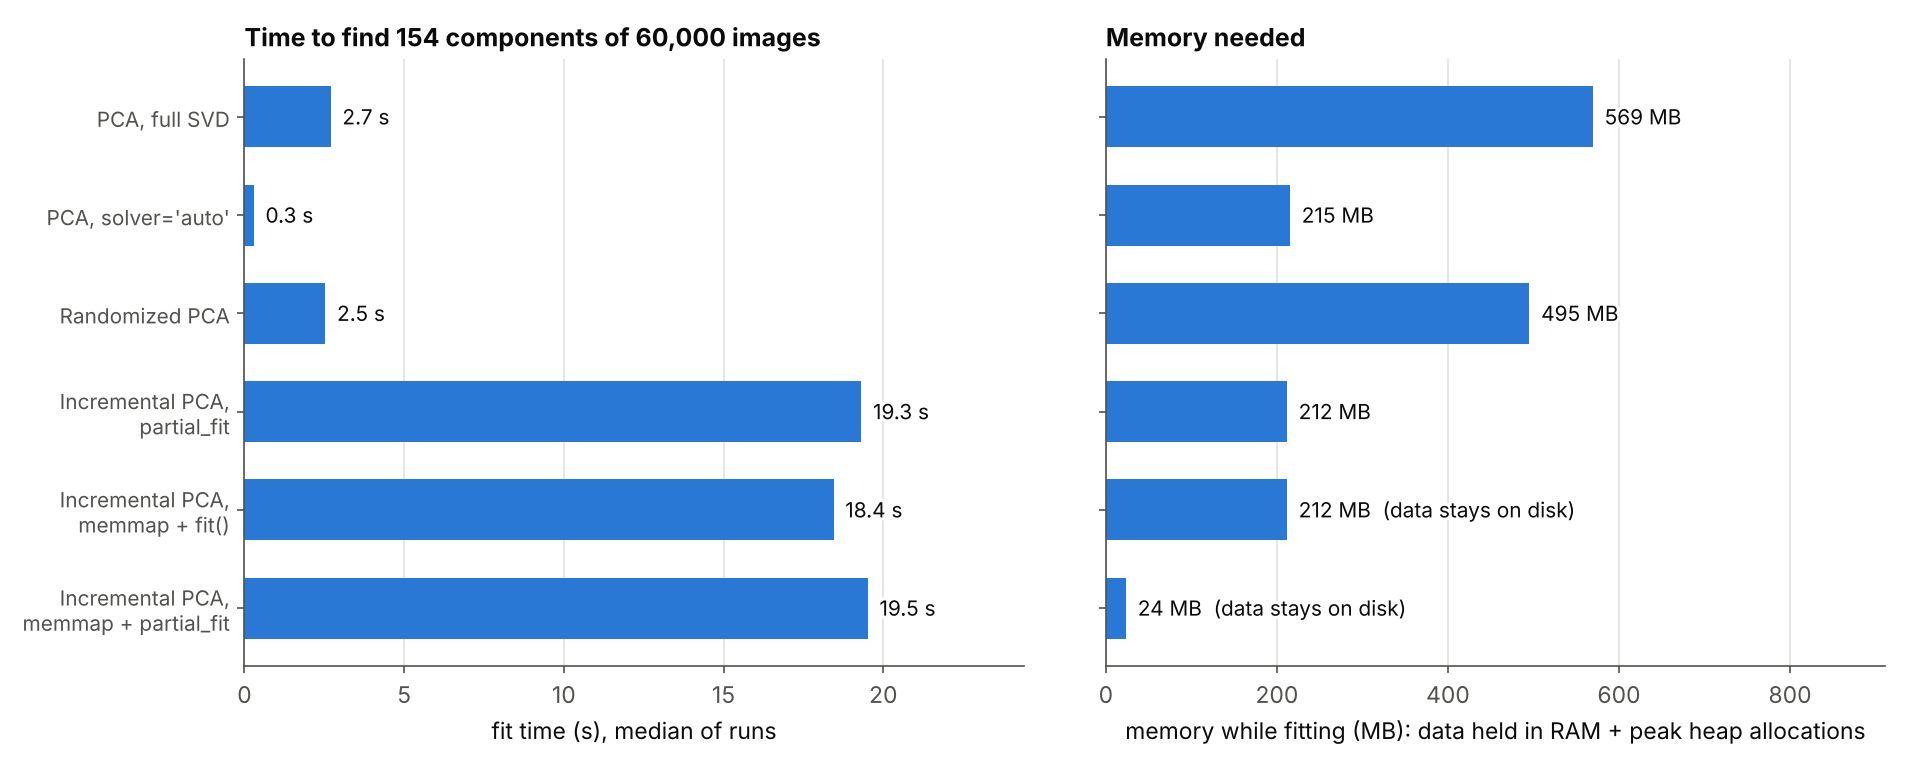

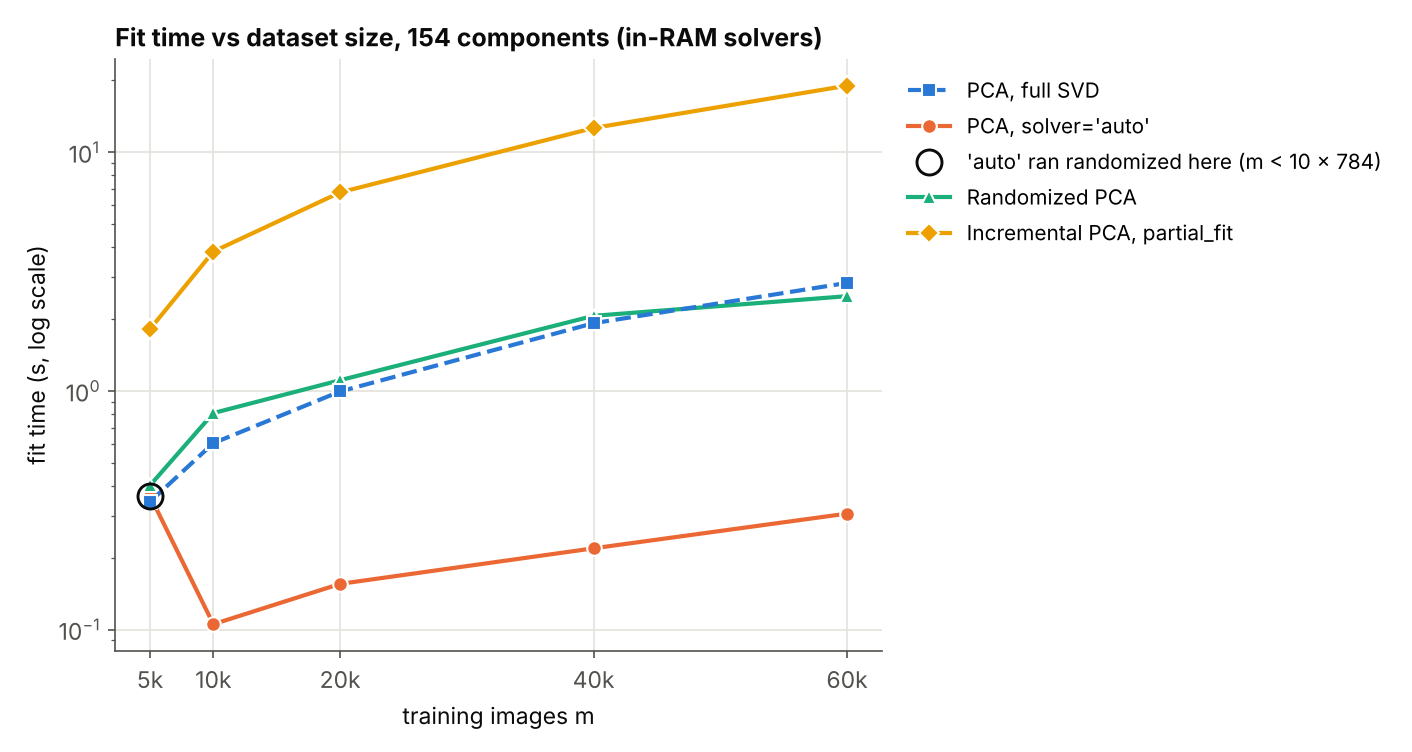

In [7]:
from dimred_mlops import plots
plots.solver_comparison(b.solvers, FIG / "b_solvers.png")
plots.timing_curve(b.timing_curve, FIG / "b_timing_curve.png")
display(Image(str(FIG / "b_solvers.png"), width=900)); display(Image(str(FIG / "b_timing_curve.png"), width=700))

## Takeaways
* All solvers find practically the same 154-dimensional subspace: their test reconstruction errors are within 1% of the exact SVD.
* With only 784 features, the randomized solver is not "dramatically faster" here. Each randomized pass still multiplies the m × n data by an n × (d + 10) block, which costs O(m·n·d), and here d/n ≈ 0.2, so the saving over the exact methods is small. The book's complexity argument pays off when d ≪ n. scikit-learn ≥ 1.5 now picks a covariance-eigendecomposition solver for tall data (m ≫ n), which is the fastest of all.
* For out-of-core training, feed memmap slices to `partial_fit`; `fit()` on a memmap copies the data into memory.